# **PROBLEMA DE REGRESIÓN**
## **Actividad 2 - Laboratorio**
### Técnicas Multivariantes y Machine Learning
### Máster en Ingeniería Matemática y Computación
### UNIR

*Javier Blanco Álvarez*

Diciembre 2024

In [ ]:
# Importando librerías y dependencias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm



from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import f_regression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

## 1. Conjunto de datos ficticio

https://www.interior.gob.es/opencms/es/servicios-al-ciudadano/tramites-y-gestiones/dni/calculo-del-digito-de-control-del-nif-nie/

In [ ]:
seed_number = '51779264P'
# por calculo de digito de control, se tiene que P = 8
seed_number = '517792648'
# Si tiene más de 8 digitos, seleccionaremos los primeros 8 valores desde la derecha
seed_number = '17792648'
# Si hay valores numéricos menores de 2, se sustituye por 2
seed_number = '27792648'


In [ ]:
# Creando el conjunto de datos ficticio

n_samples = 200 + 10*int(seed_number[0]) #samples
n_features = 10 + int(seed_number[1]) + int(seed_number[2]) #features
bias = 2 #sesgo
noise = 10*int(seed_number[4]) #noise
n_informative = 10 + int(seed_number[1]) #informative variables
random_state = int(seed_number) #random state
shuffle = False #shuffle true o false

#Creando conjunto de datos con make_regression
X, y = make_regression(n_samples=n_samples,
                       n_features=n_features,
                       noise=noise,
                       random_state=random_state,
                       n_informative=n_informative,
                       bias=bias,
                       shuffle=shuffle,
                       coef=False)

In [ ]:
#Dimensiones de el conjunto de variables predictoras o atributos y variable explicativa o target
X.shape, y.shape

((220, 24), (220,))

Con la implementación mostrada hemos creado un conjunto de datos ficticio conformado por `220` registros (samples) y `24` atributos. Además, le fue aplicado un ruido gaussiano con valor `20`. De los `24` atributos, `17` son variables informativas; es decir, son aquellas que aportan mayor significancia a la variable explicativa (`target`). Un bias de `2` indica que cuando la variable de entrada (x) sea cero, el modelo predecirá un valor de salida igual a `2`. Finalmente, el conjunto generado no fue sometido a una reordenación aleatoria (`shuffle = False`)

## 2. Análisis Exploratorio
Aplicaremos de análisis exploratorio de los datos generados a fin de obtener una comprensión general y preliminar del conjunto estudiado.

In [ ]:
# Creamos un dataframe con atributos y target
df = pd.DataFrame(X)
df['target'] = y
# Aplicamos describe e info para conocer los estadísticos y el tipo de variable que conforman el dataset
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       220 non-null    float64
 1   1       220 non-null    float64
 2   2       220 non-null    float64
 3   3       220 non-null    float64
 4   4       220 non-null    float64
 5   5       220 non-null    float64
 6   6       220 non-null    float64
 7   7       220 non-null    float64
 8   8       220 non-null    float64
 9   9       220 non-null    float64
 10  10      220 non-null    float64
 11  11      220 non-null    float64
 12  12      220 non-null    float64
 13  13      220 non-null    float64
 14  14      220 non-null    float64
 15  15      220 non-null    float64
 16  16      220 non-null    float64
 17  17      220 non-null    float64
 18  18      220 non-null    float64
 19  19      220 non-null    float64
 20  20      220 non-null    float64
 21  21      220 non-null    float64
 22  22

In [ ]:
print(df.describe())

                0           1           2           3           4           5  \
count  220.000000  220.000000  220.000000  220.000000  220.000000  220.000000   
mean    -0.026547    0.108604    0.018768    0.107547    0.068529    0.023402   
std      1.048113    1.120703    1.003257    1.011946    1.076720    0.973372   
min     -3.599368   -2.973677   -3.145644   -3.264993   -3.263203   -2.466850   
25%     -0.680670   -0.616898   -0.666028   -0.552983   -0.672756   -0.761405   
50%      0.038665    0.125816    0.006387    0.129865    0.052953    0.038175   
75%      0.632161    0.928500    0.804414    0.713480    0.744211    0.745163   
max      2.710034    3.749277    2.569380    3.074207    2.960882    2.538377   

                6           7           8           9  ...          15  \
count  220.000000  220.000000  220.000000  220.000000  ...  220.000000   
mean    -0.101269    0.078648   -0.026947   -0.118984  ...    0.036188   
std      0.976421    1.028706    1.092339    0.9

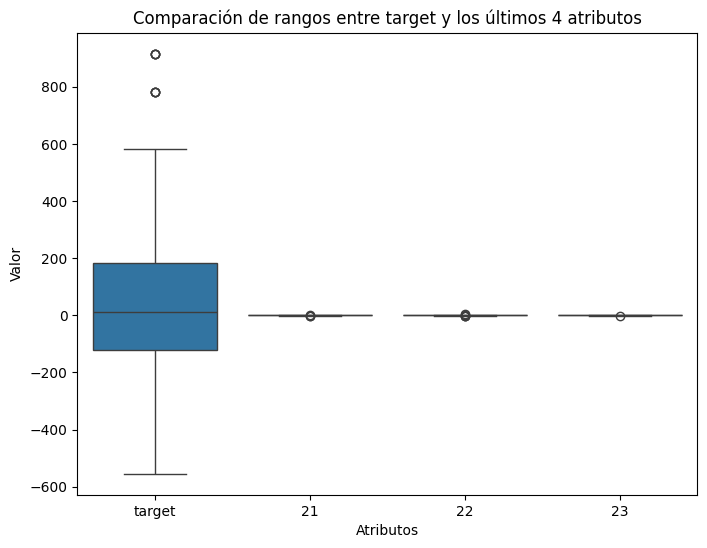

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['target', df.columns[-4], df.columns[-3], df.columns[-2], df.columns[-1]]])
plt.title('Comparación de rangos entre target y los últimos 4 atributos')
plt.ylabel('Valor')
plt.xlabel('Atributos')
plt.show()

In [ ]:
#Escalado de datos mediante transformación de la variable dependiente
scaler = MinMaxScaler()
df['target'] = scaler.fit_transform(df[['target']])
# print(df.describe())

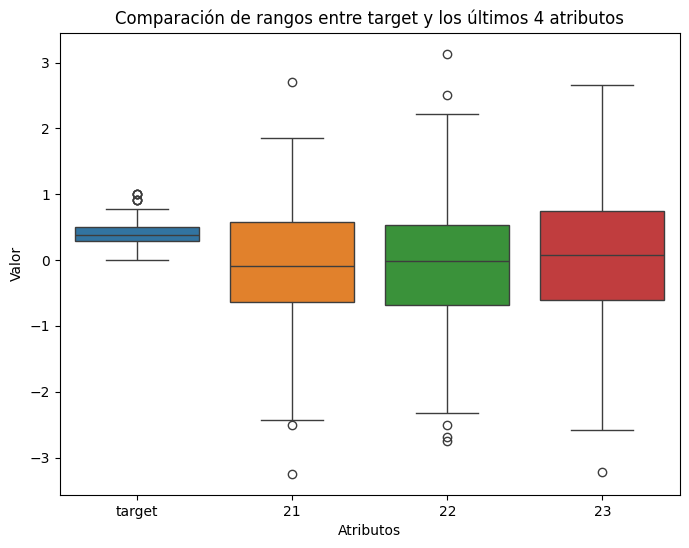

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['target', df.columns[-4], df.columns[-3], df.columns[-2], df.columns[-1]]])
plt.title('Comparación de rangos entre target y los últimos 4 atributos')
plt.ylabel('Valor')
plt.xlabel('Atributos')
plt.show()

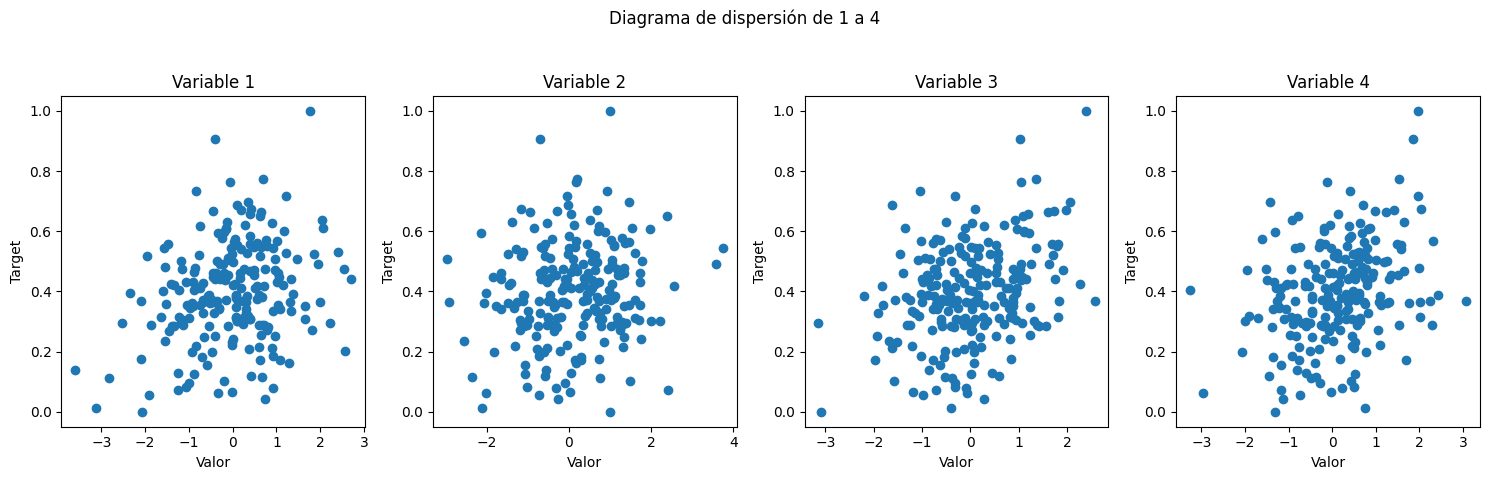

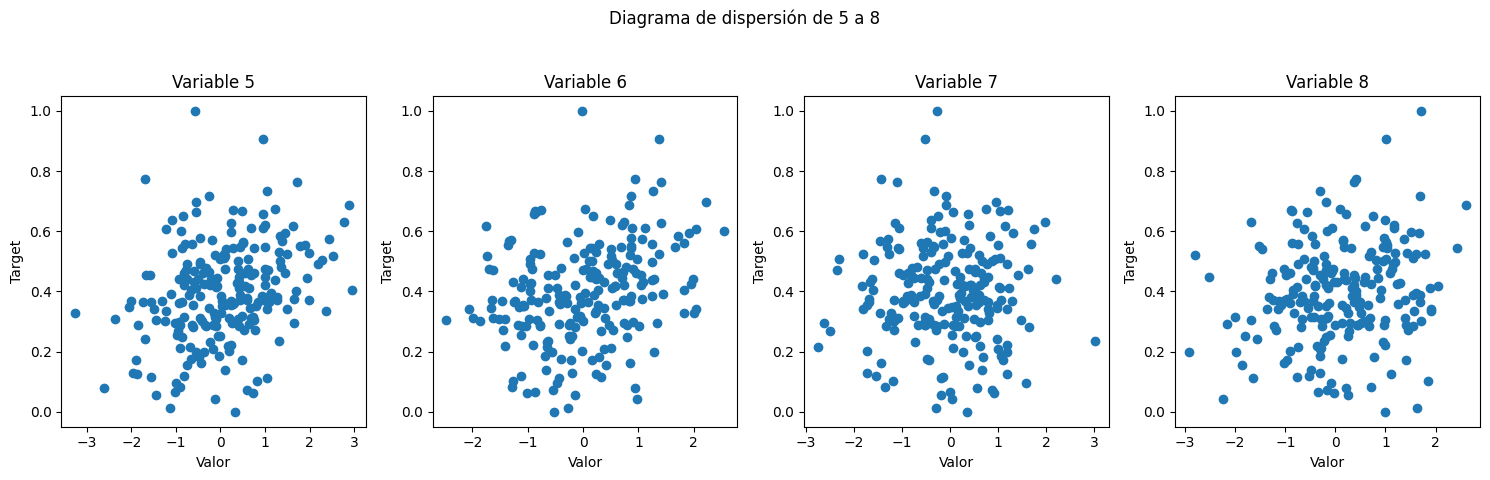

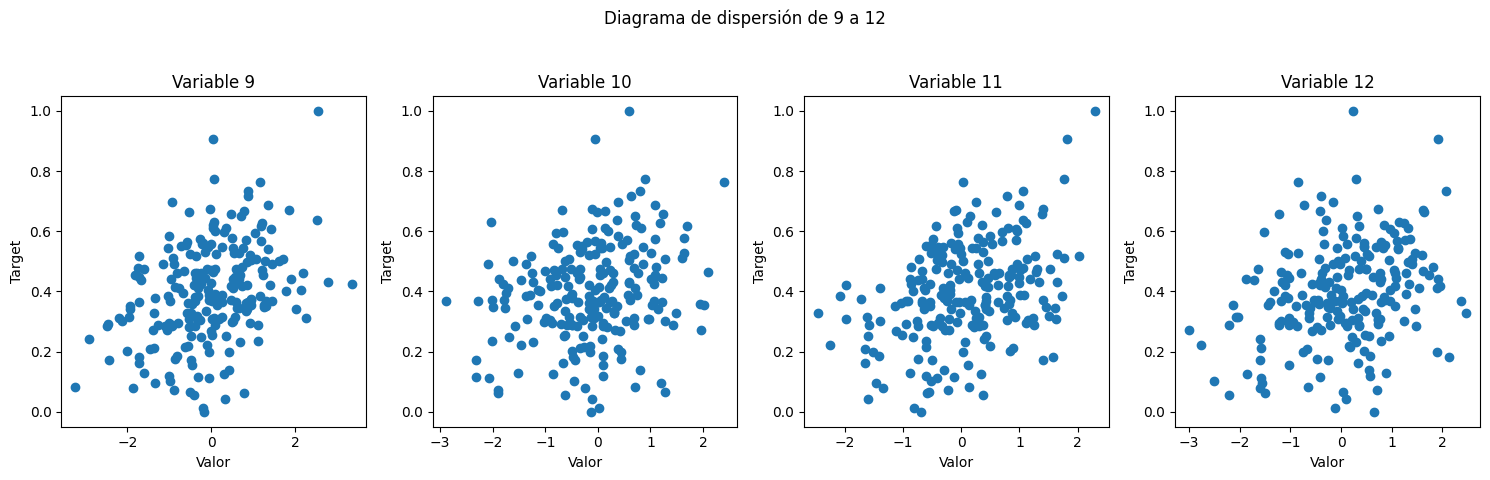

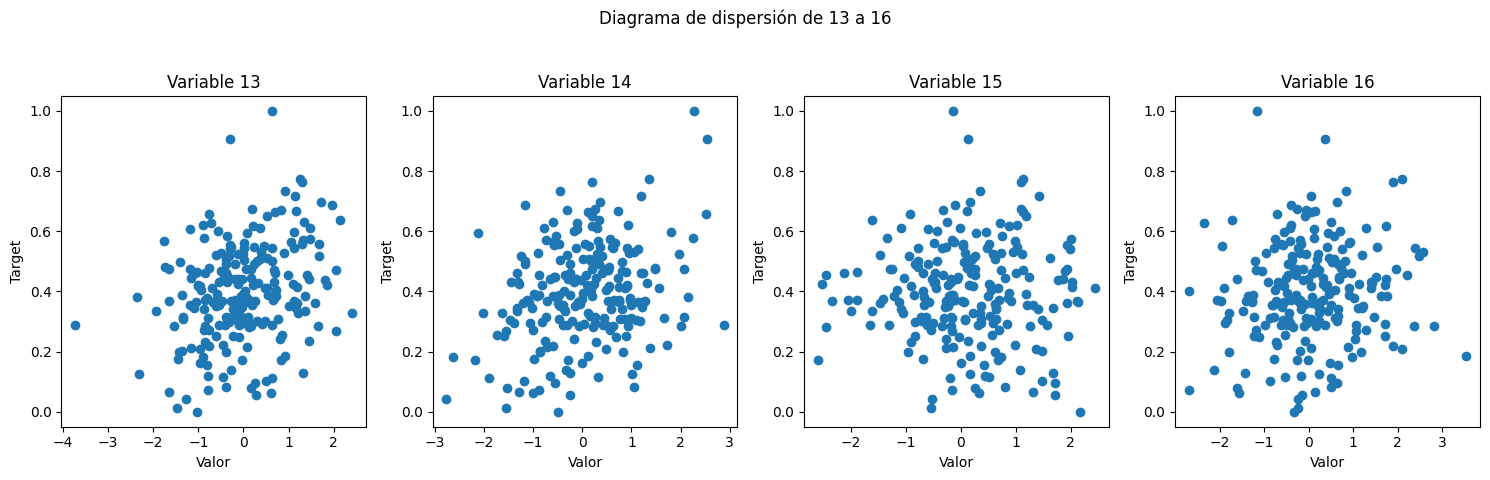

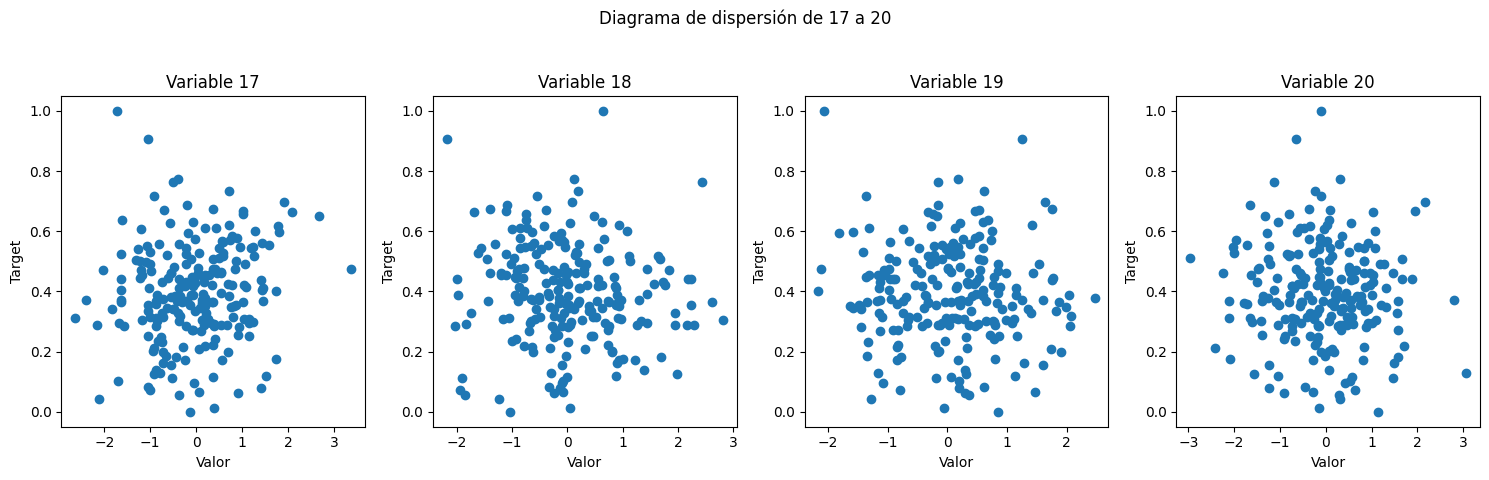

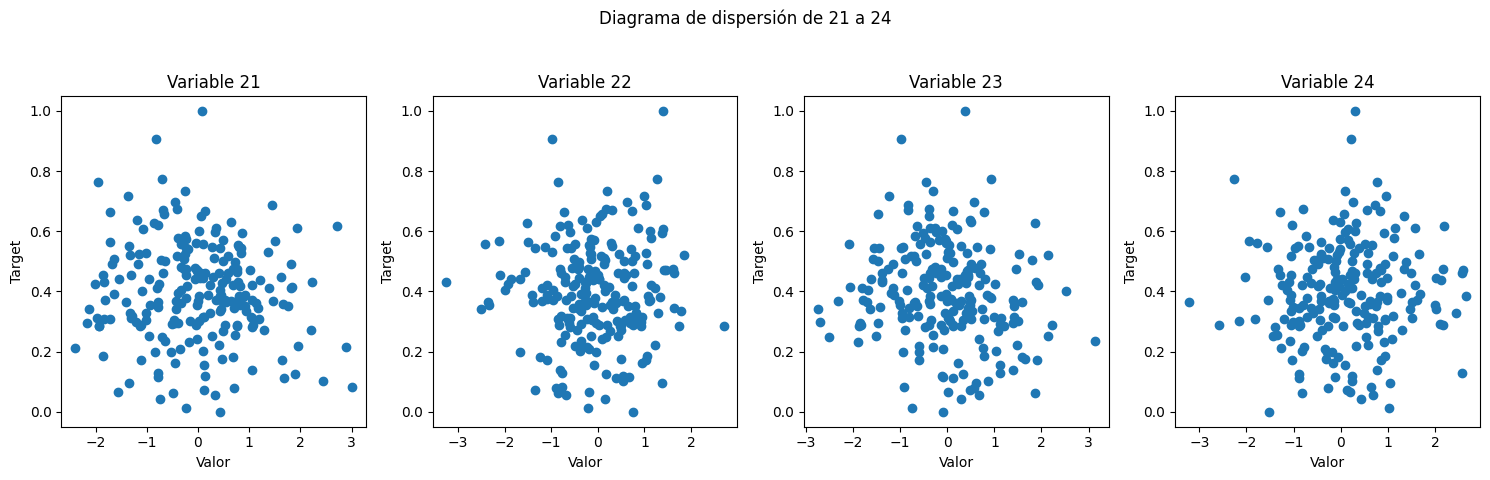

In [ ]:
n_features = n_features
y = df['target']
for i in range(0, n_features, 4):
    fig, axes = plt.subplots(1, min(4, n_features - i), figsize=(15, 5)) # Subplots
    fig.suptitle(f'Diagrama de dispersión de {i+1} a {min(i + 4, n_features)}')

    for j in range(min(4, n_features - i)):
        axes[j].scatter(X[:, i + j], y)  # Scatter plot (dispersión)
        axes[j].set_title(f'Variable {i + j + 1}')
        axes[j].set_xlabel('Valor')
        axes[j].set_ylabel('Target')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajutando layout para evitar solape
    plt.show()

## 3. MODELADO PRELIMINAR y ANÁLISIS

In [ ]:
# Dividimos el conjunto de datos en train y test
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=200, random_state=random_state)

# Modelo de regresión lineal múltiple
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes e intercepto
coefficients = model.coef_
intercept = model.intercept_

print("Coeficientes:", coefficients)
print("\n")
print("Intercepto:", intercept)

# Predicciones en el conjunto de validación
y_pred = model.predict(X_val)

# Evaluación del modelo
mse = mean_squared_error(y_val, y_pred) #Error cuadrático medio
r2 = r2_score(y_val, y_pred) # Bondad de ajuste

print("\n")
print("Error cuadrático medio:", mse)
print("R^2:", r2)

Coeficientes: [ 2.48350008e-02  2.22238864e-02  5.62830144e-02  5.47393012e-02
  5.15160118e-02  5.17219048e-02  4.56397748e-03  6.99636248e-03
  4.55987840e-02  2.58040327e-02  5.94186969e-02  3.29691116e-02
  5.25232500e-02  4.08527498e-02  1.16448632e-02  1.06917924e-02
  3.54306147e-02 -2.15035907e-03 -4.30365649e-04  4.08393490e-04
  3.87389916e-04 -1.07650850e-03 -5.23912507e-04  4.69887357e-05]


Intercepto: 0.3792872131045267


Error cuadrático medio: 0.00016840507211291812
R^2: 0.9914289148103113


## 4. Justificación del modelo
### 4.1. Selección de variables mediante Análisis de Colinealidad

In [ ]:
# Matriz de varianzas-covarianzas
from numpy.linalg import eig
df_X = df.drop('target', axis=1)
cov_matrix = df_X.cov()
# Calculando autodescomposición
values, vectors = eig(cov_matrix)

# VIF (Variance Inflation Factor)
vif = 1 / (1 - values)

colinarity_df = pd.DataFrame({'Autovalores':values,
                              'Inflación de Varianza':vif,
                              'Variables':df_X.columns}).sort_values(by='Inflación de Varianza',
                                                                     ascending=False)

colinarity_df = colinarity_df[colinarity_df['Inflación de Varianza'] > 4]

# Sabemos entonces que podemos descartar las variables:
print('Variables con VIF > 4 y por tanto a descartar:')
print(colinarity_df['Variables'].to_list())


print("\n")
print("Variables elegidas para la regresión:")
X_filtered = df_X.drop(columns=colinarity_df['Variables'].to_list())
print(X_filtered.columns)

Variables con VIF > 4 y por tanto a descartar:
[15, 19, 20, 21, 23, 22, 18]


Variables elegidas para la regresión:
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17], dtype='object')


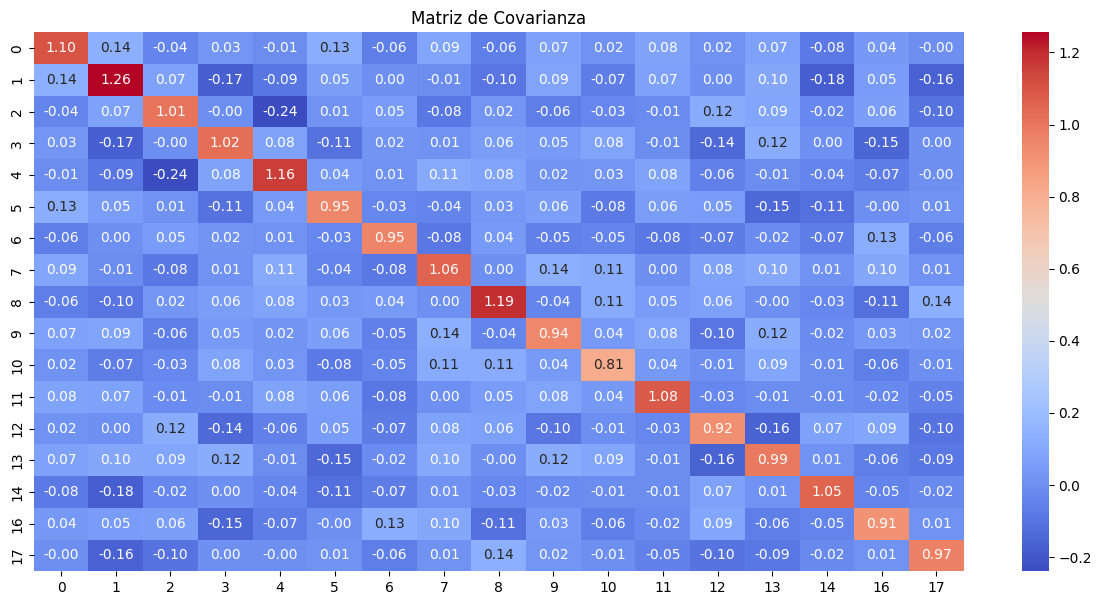

In [ ]:
cov_matrix = X_filtered.cov()
plt.figure(figsize=(15, 7))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Matriz de Covarianza')
plt.show()

### 4.2. Selección de variables mediante Información Mutua

La información mutua (MI) es una medida que indica cuán relacionadas están dos variables aleatorias. Cuanto mayor sea el valor de la información mutua, más dependientes serán las variables. Si las variables son completamente independientes, la información mutua será cero.
Esta medida se calcula utilizando técnicas estadísticas avanzadas que no hacen suposiciones previas sobre la distribución de los datos. Estas técnicas se basan en la estimación de la entropía de los datos, la cual se calcula a partir de las distancias entre cada punto de datos y sus K vecinos más cercanos (K-NEAREST).

In [ ]:
#Análisis de información Mutua
mi = mutual_info_regression(X, y)
df_mi = pd.DataFrame({'Variable': [f'{i+1}' for i in range(n_features)], 'Mutual Info': mi})
df_mi.sort_values(by='Mutual Info', ascending=False)

#Observamos que las variables 6, 1, 7, 9, 13, 11, 5, 22, 23 y 16 son las 10 variables más relacionadas con el target (y)

,Variable,Mutual Info
5,6,0.118801
0,1,0.101810
6,7,0.090216
8,9,0.086141
12,13,0.075770
10,11,0.067780
4,5,0.063172
21,22,0.060909
22,23,0.059053
15,16,0.051980


### 4.3. Selección de variables mediante Pruebas de Hipótesis

In [ ]:
f_statistic, p_values = f_regression(X, y)

statistics_df = pd.DataFrame({'Variable':[f'{i+1}' for i in range(n_features)],'Estadístico F': f_statistic, 'p_valor': p_values, 'Mutual Info': mi})
statistics_df['p_valor'] = statistics_df['p_valor'].round(8)
statistics_df['Hipotesis'] = statistics_df['p_valor'].apply(lambda p: 'Rechaza' if p < 0.0500 else 'Acepta')

# Significancia de las variables predictoras (usando los p-valores del análisis previo)
# Se asume que el analisis previo (statistics_df) contiene la información de p-values
significativas = statistics_df[statistics_df['p_valor'] < 0.05]
no_significativas = statistics_df[statistics_df['p_valor'] >= 0.05]

print("\n")
print("\nVariables predictoras significativas (p-valor < 0.05):")
print(significativas)

print("\nVariables predictoras no significativas (p-valor >= 0.05):")
print(no_significativas)

# Conclusión sobre la significancia de las variables
if len(no_significativas) > 0:
    print("\nNo todas las variables predictoras son significativas.")
else:
    print("\nTodas las variables predictoras son significativas (según el umbral de p-valor < 0.05).")




Variables predictoras significativas (p-valor < 0.05):
   Variable  Estadístico F       p_valor  Mutual Info Hipotesis
0         1      15.490149  1.115500e-04     0.101810   Rechaza
2         3      25.504674  9.300000e-07     0.000000   Rechaza
3         4      24.087495  1.800000e-06     0.000000   Rechaza
4         5      22.678686  3.490000e-06     0.063172   Rechaza
5         6      19.041170  1.975000e-05     0.118801   Rechaza
7         8       7.083335  8.359630e-03     0.014415   Rechaza
8         9      32.729365  3.000000e-08     0.086141   Rechaza
9        10      12.976000  3.907800e-04     0.000000   Rechaza
10       11      37.931149  0.000000e+00     0.067780   Rechaza
11       12      19.136893  1.886000e-05     0.029187   Rechaza
12       13      18.810319  2.207000e-05     0.075770   Rechaza
13       14      20.186838  1.139000e-05     0.029439   Rechaza
22       23       4.667368  3.183158e-02     0.059053   Rechaza

Variables predictoras no significativas (p-va

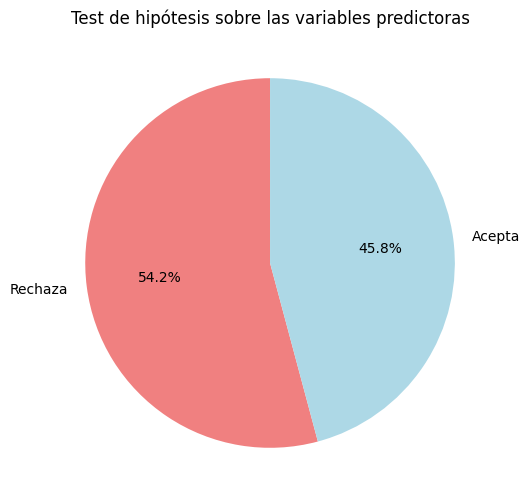

In [ ]:
#Pintamos el test de hipótesis
plt.figure(figsize=(6, 6))
hypothesis_counts = statistics_df['Hipotesis'].value_counts()
plt.pie(hypothesis_counts, labels=hypothesis_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue'])
_ = plt.title('Test de hipótesis sobre las variables predictoras')
plt.show()

### 4.4. Selección de Variables mediante Stepwise

In [ ]:
# Inspirado en la implementación de Dale, 2017
# https://datascience.stackexchange.com/a/24447

def stepwise_selection(X, y,
                      initial_list=[],
                      threshold_in=0.01,
                      threshold_out=0.05,
                      verbose=True):
    """ Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    # Obtenemos número de variables
    n_features = X.shape[1]

    max_iteration = n_features
    iteration = 0
    included = list(initial_list)

    while iteration < max_iteration:
        changed = False
        # Selección hacia delante
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]

        if len(new_pval) > 0:  # Verifica si hay candidato para añadir
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print('Agregando  {:30} con p-valor {:.8}'.format(best_feature, best_pval))

        # Selección hacia atrás
        if len(included) > 0:  # Verifica si hay variables candidatas para remover
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
            # usa todos los coeficientes menos el intercepto
            pvalues = model.pvalues.iloc[1:]
            if len(pvalues) > 0:  # verifica si hay p-valores por evaluar
                worst_pval = pvalues.max()
                if worst_pval > threshold_out:
                    changed = True
                    worst_feature = pvalues.idxmax()
                    included.remove(worst_feature)
                    if verbose:
                        print('Removiendo {:30} con p-valor {:.6}'.format(worst_feature, worst_pval))

        if not changed:
            break

        iteration += 1
    return included

step_wise_result = stepwise_selection(df_X, y)
print('Variables seleccionadas:')
print(step_wise_result)

Agregando                              10 con p-valor 3.4867499e-09
Agregando                               2 con p-valor 2.2134646e-08
Agregando                               4 con p-valor 6.3313649e-12
Agregando                               5 con p-valor 2.6241069e-09
Agregando                               3 con p-valor 7.7136149e-10
Agregando                              12 con p-valor 1.945405e-11
Agregando                              13 con p-valor 2.2045861e-14
Agregando                              11 con p-valor 5.3034769e-14
Agregando                               8 con p-valor 1.4155364e-16
Agregando                              16 con p-valor 9.6043168e-21
Agregando                               0 con p-valor 2.842615e-20
Agregando                               9 con p-valor 1.2471324e-29
Agregando                               1 con p-valor 9.190511e-34
Agregando                              14 con p-valor 2.7642312e-17
Agregando                              15 con p-val

Las variables elegidas son:


In [ ]:
col_names = df_X.columns
col_names = [f'Variable {i+1}' for i in range(len(col_names))]
col_names = [str(x) for x in col_names]


no_colinarity_values = X_filtered
no_colinarity_vars = [str(x) for x in no_colinarity_values]
mutual_info_vars = df_mi.sort_values(by='Mutual Info', ascending=False).head(10)['Variable'].to_list()
hypothesis_vars = significativas['Variable'].to_list()
stepwise_vars = step_wise_result

# Create the DataFrame
data = {
    'Método': ['No Colinealidad', 'Información Mutua', 'Prueba de Hipótesis', 'Stepwise'],
    'Variables Seleccionadas': [no_colinarity_vars, mutual_info_vars, hypothesis_vars, stepwise_vars]
}
comparison_df = pd.DataFrame(data)
comparison_df = comparison_df.set_index('Método')
comparison_df


,Variables Seleccionadas
Método,
No Colinealidad,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
Información Mutua,"[6, 1, 7, 9, 13, 11, 5, 22, 23, 16]"
Prueba de Hipótesis,"[1, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 23]"
Stepwise,"[10, 2, 4, 5, 3, 12, 13, 11, 8, 16, 0, 9, 1, 1..."


In [ ]:
# # Convertiremos la columna de variables en listas de enteros
# comparison_df['Variables Seleccionadas'] = comparison_df['Variables Seleccionadas'].astype(str)
# comparison_df['Variables Seleccionadas'] = comparison_df['Variables Seleccionadas'].str.replace("[", "").str.replace("]", "").str.replace("'", "")
# comparison_df['Variables Seleccionadas'] = comparison_df['Variables Seleccionadas'].str.split(',')
# comparison_df['Variables Seleccionadas'] = comparison_df['Variables Seleccionadas'].apply(lambda x: [int(i) for i in x])


# # Obtener una lista con los conjuntos de variables para cada método
# sets_of_variables = comparison_df['Variables Seleccionadas'].tolist()

# sets_of_variables = [set(var_list) for var_list in sets_of_variables] # This line is changed

# # Encontrar la intersección de todos los conjuntos
# common_variables = set.intersection(*sets_of_variables)

# print("Variables comunes a todos los métodos:", common_variables)

## 5. REGRESIÓN LINEAL MÚLTIPLE

### 5.1. Planteamiento del modelo

In [ ]:
X = df_X[stepwise_vars]
y = df['target']

# Dividimos el conjunto de datos en train y test
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=200, random_state=random_state)

# Modelo de regresión lineal múltiple
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes e intercepto
coefficients = model.coef_
intercept = model.intercept_

print("Coeficientes:", coefficients)
print("\n")
print("Intercepto:", intercept)

# Predicciones en el conjunto de validación
y_pred = model.predict(X_val)

# Evaluación del modelo
mse = mean_squared_error(y_val, y_pred) #Error cuadrático medio
r2 = r2_score(y_val, y_pred) # Bondad de ajuste

print("\n")
print("Error cuadrático medio:", mse)
print("R^2:", r2)

Coeficientes: [0.05966662 0.05632362 0.05152243 0.05178323 0.05476862 0.05298393
 0.04107157 0.03312434 0.04533869 0.03532867 0.02471121 0.02574089
 0.02247967 0.0116917  0.01050319 0.00686625 0.00474928]


Intercepto: 0.37926046968018984


Error cuadrático medio: 0.0001453805411212889
R^2: 0.9926007632238172


### 5.2. Comprobación del modelo

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     1757.
Date:                Fri, 03 Jan 2025   Prob (F-statistic):          7.23e-192
Time:                        16:16:28   Log-Likelihood:                 585.94
No. Observations:                 200   AIC:                            -1136.
Df Residuals:                     182   BIC:                            -1077.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3793      0.001    375.102      0.0

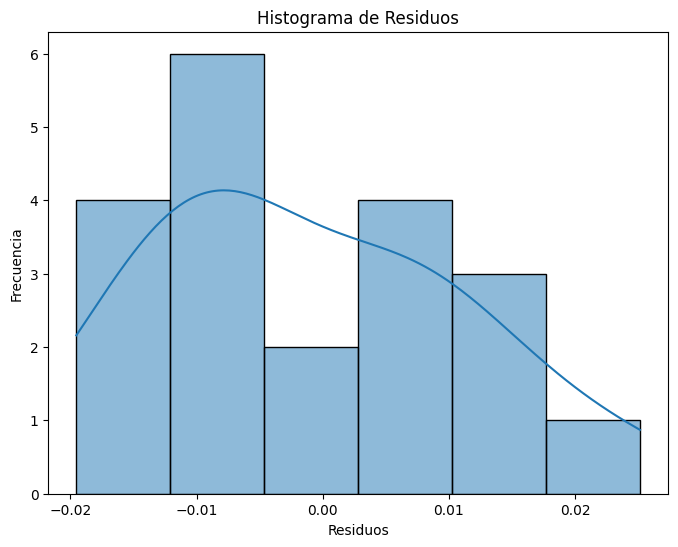

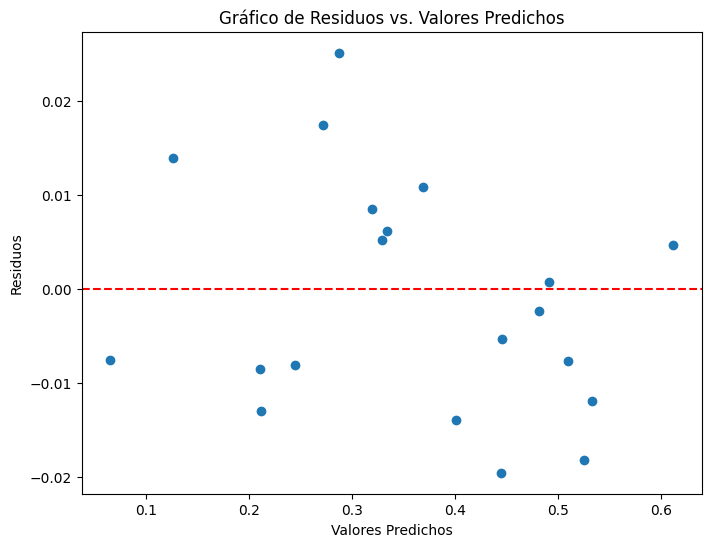

Estadístico de Durbin-Watson: 2.19521211195722
Test de Shapiro-Wilk: ShapiroResult(statistic=0.9636108631896402, pvalue=0.6182180182507153)
Test de Breusch-Pagan: (17.394150529097537, 0.42798669377932475, 0.7852988721460413, 0.6947382131288068)


In [ ]:

# Add a constant to the independent variables
X_train_const = sm.add_constant(X_train)
X_val_const = sm.add_constant(X_val)

# Fit the OLS model
model_ols = sm.OLS(y_train, X_train_const).fit()

# Print the model summary
print(model_ols.summary())

# Analyze residuals
residuals = y_val - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title("Histograma de Residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')  # Línea horizontal en y=0
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos vs. Valores Predichos")
plt.show()

#Test de Durbin Watson para detectar autocorrelación en residuos
from statsmodels.stats.stattools import durbin_watson
dw_statistic = durbin_watson(residuals)
print(f"Estadístico de Durbin-Watson: {dw_statistic}")

# Test de normalidad de residuos (Shapiro-Wilk)
from scipy.stats import shapiro
shapiro_test = shapiro(residuals)
print(f"Test de Shapiro-Wilk: {shapiro_test}")

# Test de homocedasticidad (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X_val_const)
print(f"Test de Breusch-Pagan: {bp_test}")

Se han realizado pruebas estadísticas para evaluar la validez de las suposiciones fundamentales de un modelo de regresión lineal. Los resultados obtenidos son los siguientes:

Prueba de Durbin-Watson: El estadístico de Durbin-Watson, con un valor de 2.193, sugiere la ausencia de autocorrelación en los residuos del modelo. Esto indica que los errores no están relacionados entre sí, lo cual es un requisito crucial para la validez de la regresión.

Prueba de Shapiro-Wilk: La prueba de Shapiro-Wilk, con un p-valor de 0.6190, no proporciona evidencia suficiente para rechazar la hipótesis nula de normalidad de los residuos. Por lo tanto, se puede asumir que los residuos se distribuyen aproximadamente de manera normal, condición necesaria para la inferencia estadística.

Prueba de Breusch-Pagan: La prueba de Breusch-Pagan, con un p-valor de 0.4269, no evidencia heteroscedasticidad en los datos. Esto significa que la varianza de los residuos es constante, otro supuesto importante para la confiabilidad del modelo de regresión.

En conjunto, los resultados de estas pruebas diagnósticas indican que el modelo de regresión lineal cumple con las principales suposiciones de ausencia de autocorrelación, normalidad de los residuos y homocedasticidad. Estos hallazgos respaldan la validez del modelo y la confiabilidad de las inferencias que se puedan extraer de él.

## 6. Regresión Lineal Avanzada
### 6.1 Regresión Lineal Penalizada Ridge

In [ ]:
X = df_X
y = df['target']

# Dividimos el conjunto de datos en train y test
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=200, random_state=random_state)

In [ ]:
# Definir algunos valores de alpha
alphas = np.linspace(0.01, 2, 20)

# Asignamos espacio en la memoria mediante un diccionario
resultados_ridge = {}

for alpha in alphas:
    # Creando y entrenando modelo penalizado Ridge
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)

    # Predicciones con Ridge
    y_pred = ridge_model.predict(X_val)

    # Validación del modelo
    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    resultados_ridge[alpha] = {'mse': mse, 'r2': r2}

# Mostrar resultados en el notebook
for alpha, metrics in resultados_ridge.items():
    print(f"Alpha: {alpha}, MSE: {metrics['mse']}, R^2: {metrics['r2']}")

#Encontrar el mejor alpha basandose en el MSE (o R^2)
best_alpha_ridge = min(resultados_ridge, key=lambda k: resultados_ridge[k]['mse'])
print(f"\nEl mejor valor de alpha es: {best_alpha_ridge} con un MSE de {resultados_ridge[best_alpha_ridge]['mse']}")

Alpha: 0.01, MSE: 0.0001683747293511196, R^2: 0.9914304591248203
Alpha: 0.11473684210526315, MSE: 0.00016806422093526595, R^2: 0.9914462626517035
Alpha: 0.21947368421052632, MSE: 0.00016776698821440117, R^2: 0.991461390503494
Alpha: 0.3242105263157895, MSE: 0.00016748297785568647, R^2: 0.9914758453946012
Alpha: 0.42894736842105263, MSE: 0.00016721213677087145, R^2: 0.9914896300269861
Alpha: 0.5336842105263158, MSE: 0.00016695441211493417, R^2: 0.9915027470902301
Alpha: 0.638421052631579, MSE: 0.0001667097512847205, R^2: 0.9915151992616049
Alpha: 0.7431578947368421, MSE: 0.00016647810191760046, R^2: 0.9915269892061406
Alpha: 0.8478947368421053, MSE: 0.00016625941189013103, R^2: 0.9915381195766932
Alpha: 0.9526315789473684, MSE: 0.00016605362931672497, R^2: 0.9915485930140137
Alpha: 1.0573684210526315, MSE: 0.0001658607025483353, R^2: 0.9915584121468135
Alpha: 1.1621052631578948, MSE: 0.0001656805801711387, R^2: 0.9915675795918325
Alpha: 1.266842105263158, MSE: 0.0001655132110052377, R^2

### 6.2. Regresión Lineal Penalizada Lasso

In [ ]:
# Repetimos el procedimiento anterior pero utilizando la regresión
# Penalizada Lasso
resultados_lasso = {}

for alpha in alphas:
    # Creando y entrenando modelo Lasso
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)

    # Predicciones con Lasso
    y_pred = lasso_model.predict(X_val)

    # Validando el modelo
    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    resultados_lasso[alpha] = {'mse': mse, 'r2': r2}

# Mostrando resultados
for alpha, metrics in resultados_lasso.items():
    print(f"Alpha: {alpha}, MSE: {metrics['mse']}, R^2: {metrics['r2']}")

# Encontrar el mejor alpha basandose en el MSE (o R^2)
best_alpha_lasso = min(resultados_lasso, key=lambda k: resultados_lasso[k]['mse'])
print(f"\nEl mejor valor de alpha es: {best_alpha_lasso} con un MSE de {resultados_lasso[best_alpha_lasso]['mse']}")

Alpha: 0.01, MSE: 0.002022177237061938, R^2: 0.8970799801333434
Alpha: 0.11473684210526315, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.21947368421052632, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.3242105263157895, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.42894736842105263, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.5336842105263158, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.638421052631579, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.7431578947368421, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.8478947368421053, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 0.9526315789473684, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 1.0573684210526315, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 1.1621052631578948, MSE: 0.02127659967590454, R^2: -0.08288631738362473
Alpha: 1.266842105263158, MSE: 0.02127659967590454, R^2: -0.08288

### 6.3. Regresión Lineal con Red Elástica

In [ ]:
# Regresión mediante La Red Elástica.
# Probaremos distintos valores de r (ratio entre Ridge y Lasso) y encontraremos valores óptimos de r y alpha con
# validación cruzada

# Valores de Alphas y ratio r
alphas = np.linspace(0.001, 2, 100)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Red Elástica (configuración y ajuste)
elastic_net_model = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=10) # Usamos 10 validaciones cruzadas
elastic_net_model.fit(X_train, y_train)

# Ratio y alpha óptimo
print("Alpha óptimo:", elastic_net_model.alpha_)
print("l1_ratio óptimo:", elastic_net_model.l1_ratio_)

# Predicciones sobre el conjunto de validación
y_pred = elastic_net_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("Error cuadrático medio:", mse)
print("Coeficiente de determinación R^2:", r2)

Alpha óptimo: 0.001
l1_ratio óptimo: 0.3
Error cuadrático medio: 0.00015947871978855768
Coeficiente de determinación R^2: 0.9918832272917902


### 6.4. Selección del mejor modelo avanzado

In [ ]:

# Asignamos espacio en memoria para guardar los distintos MSE
model_mse = {}

# # Regresión Lineal Múltiple
# y_pred_linear = model.predict(X_val)
# model_mse['Linear Regression'] = mean_squared_error(y_val, y_pred_linear)

# Regresión Ridge
ridge_model = Ridge(alpha = best_alpha_ridge)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_val)
model_mse['Ridge Regression'] = mean_squared_error(y_val, y_pred_ridge)

# Regresión Lasso
lasso_model = Lasso(alpha = best_alpha_lasso)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_val)
model_mse['Lasso Regression'] = mean_squared_error(y_val, y_pred_lasso)

# Regresión por Red Elástica
y_pred_elastic = elastic_net_model.predict(X_val)
model_mse['ElasticNet Regression'] = mean_squared_error(y_val, y_pred_elastic)


# Mejor modelo será el que tenga MSE más pequeño
best_model = min(model_mse, key=model_mse.get)
best_mse = model_mse[best_model]

print(f"\nEl modelo con menor MSE en el conjunto de validación es: {best_model} con un MSE de {best_mse}")


El modelo con menor MSE en el conjunto de validación es: ElasticNet Regression con un MSE de 0.00015947871978855768


# REFERENCIAS

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html

https://scikit-learn.org/1.5/modules/generated/sklearn.feature_selection.mutual_info_regression.html

https://scikit-learn.org/1.5/modules/generated/sklearn.feature_selection.f_regression.html


A. Kraskov, H. Stogbauer and P. Grassberger, “Estimating mutual information”. Phys. Rev. E 69, 2004.